# Tutorial C3 | Demand

This video introduces the individual's constrained optimization decision intuitively and how it gives us demand.


In [1]:
from Video import *
from part_c import *
warnings.filterwarnings('ignore')

config.background_color = 'black'
config.media_dir = 'PartF_E3'

Manim Community v0.13.1

In [2]:
%%manim -ql -v ERROR title

class title(Scene):
    def construct(self):
        title = Tex("Tutorial 04").scale(2)
        subtitle = Tex("$|$ Demand",color=GREY).scale(2).next_to(title,RIGHT)
        title_group = VGroup(title,subtitle).move_to(UP*2)
        topic_list = [
            "{{1.}} Budget Constraint",
            "{{2.}} Individual Demand",
            "{{3.}} Engel Curve",
            "{{4.}} Substitution and Income Effects",
        ]
        topic_list = [Tex(t).scale(1.5).set_color_by_tex_to_color_map({
                "1": BLUE,
                "2": BLUE,
                "3": BLUE,
                "4": BLUE,
            }) for t in topic_list]
        self.play(FadeIn(title))
        self.play(AddTextWordByWord(subtitle, run_time=2), rate_func=linear)
        self.wait()

        for i in range(len(topic_list)):
            self.play(AddTextWordByWord(topic_list[i].to_edge((i*1.5+7)*UP+LEFT), run_time=2), rate_func=linear)
        self.wait(2)

## Animation 1 | The Consumer's Problem

Use indifference curves and the budget constraint to solve the consumer's problem.

In [2]:
%%manim -ql -v ERROR animation_1

class animation_1(Scene):
    def construct(self):                
        price_a = 1
        price_b = 1
        Y = 80
        
        """ Setup Axis """
        
        axes, grid_labels = consumer_graph()
        self.add(axes, grid_labels)
        
        """ Setup Budget Line """
        
        budget = axes.plot(lambda a: budget_constraint(a, Y, price_a, price_b), 
                           color=RED, x_range=(0, Y/price_b))
        self.play(Create(budget))
        
        """ Move Point on the Budget Line """
        
        quantity_a = ValueTracker(10)
        budget_dot = always_redraw(lambda: move_budget_dot(axes, quantity_a, Y, price_a, price_b))
        
        self.add(budget_dot)
        for a in [45, 80, 80, 5]:
            self.play(quantity_a.animate.set_value(a),run_time=1)
        self.play(FadeOut(budget_dot))
        
        """ Move Point on Indifference Curve """
        
        U = ValueTracker(20)
        indifference = always_redraw(lambda: move_indifference_curve(axes, U))
        self.play(Create(indifference))
        
        indifference_dot = always_redraw(lambda: move_indifference_dot(axes, quantity_a, U))
        indifference_label = always_redraw(lambda: move_indifference_label(axes, U, indifference_dot))
        self.add(indifference_dot, indifference_label)
        
        for a in [60, 20]:
            self.play(quantity_a.animate.set_value(a),run_time=1)
        
        """ Introduce MRS on Indifference Curve """
        
        mrs_line = always_redraw(lambda: move_mrs_line(axes, quantity_a, U))
        self.play(Create(mrs_line))
        
        """ Introduce the Pointer Dot """
        
        pointer_a = ValueTracker(quantity_a.get_value())
        pointer_b = ValueTracker(indifference_curve(U, pointer_a.get_value()))
        
        pointer_dot = always_redraw(lambda: Dot(
            axes.coords_to_point(
                pointer_a.get_value(), 
                pointer_b.get_value()), 
            color=GREEN))
        self.add(pointer_dot)
        
        """ Incrementally Move Toward the Budget Line """
        
        for inc in [1, 2, 3, 4]:
            self.play(
                pointer_a.animate.set_value(pointer_a.get_value() + 5), 
                pointer_b.animate.set_value(pointer_b.get_value() + 5))
            for a_inc in [3, -6, 3]:
                self.play(quantity_a.animate.set_value(quantity_a.get_value() + a_inc), run_time=1/2)
            U_prime = utility(pointer_a, pointer_b)
            self.play(U.animate.set_value(U_prime), quantity_a.animate.set_value(pointer_a.get_value()))


## Animation 2 | Changes in the Consumer Problem

Vary income and prices with the consumer problem.

#### Note
Add value tracker number lines for prices and income on the left and right of the graph.

Make sure the indifference curve doesn't go above the 100 y.

In [3]:
%%manim -ql -v ERROR animation_2

class animation_2(Scene):
    def construct(self):
        price_a = ValueTracker(1)
        price_b = ValueTracker(1)
        Y = ValueTracker(80)
        
        """ Setup Axis """
        
        axes, grid_labels = consumer_graph()
        self.add(axes, grid_labels)
        
        """Setup Consumer Problem Graph"""

        dot = always_redraw(lambda: consumer_solution_dot(axes, Y, price_a, price_b))
        budget = always_redraw(lambda: move_budget_constraint(axes, Y, price_a, price_b))
        indifference = always_redraw(lambda: consumer_solution_indifference(axes, Y, price_a, price_b))
        label = always_redraw(lambda: consumer_solution_label(axes, Y, price_a, price_b))
        self.add(dot, budget, indifference, label)
        
        """Change Income in the Consumer Problem Graph"""
        
        for income in [50, 10, 80]:
            self.play(Y.animate.set_value(income))

        for price in [2, 3, 1/2, 1]:
            self.play(price_a.animate.set_value(price))
        
        for price in [2, 3, 1/2, 1]:
            self.play(price_b.animate.set_value(price))

AttributeError: 'numpy.float64' object has no attribute 'get_value'

In [224]:
def move_budget_constraint(axes, Y, price_a, price_b):
    """ Return a plot of the budget line. """
    
    x_max = min(100, Y.get_value()/price_a.get_value())
    x_min = min([a for a in np.arange(0, 100, 0.1) if budget_constraint(a, Y, price_a, price_b) < 100])
    
    return axes.plot(lambda a: budget_constraint(a, Y, price_a, price_b), color=RED, x_range=(x_min, x_max, 0.1))

In [222]:
def move_indifference_curve(axes, U, tracker=True):
    """ Move the MRS line along the indifference curve. """
    
    if tracker:
        x_min = min([a for a in np.arange(0, 100, 0.1) if indifference_curve(U, a) < 100])
        return axes.plot(lambda a: indifference_curve(U, a), color=YELLOW, x_range=(x_min, 100, 0.1))
    else:
        x_min = min([a for a in np.arange(0, 100, 0.1) if indifference_curve(U, a, tracker=False) < 100])
        return axes.plot(lambda a: indifference_curve(U, a, tracker=False), color=YELLOW, x_range=(x_min, 100, 0.1))

## Animation 3 | Income Consumption Path

Trace quantity bundles as income changes. And do it at various prices.

In [287]:
%%manim -qh -v ERROR animation_3_A

class animation_3_A(Scene):
    def construct(self):
        price_a = ValueTracker(1)
        price_b = ValueTracker(1)
        Y = ValueTracker(80)
        
        """ Setup Axis """
        
        axes, grid_labels = consumer_graph()
        self.add(axes, grid_labels)
        
        """Setup Consumer Problem Graph"""

        dot = consumer_solution_dot(axes, Y, price_a, price_b)
        budget = move_budget_constraint(axes, Y, price_a, price_b)
        indifference = consumer_solution_indifference(axes, Y, price_a, price_b)
        label = consumer_solution_label(axes, Y, price_a, price_b)
        self.add(dot, budget, indifference, label)
        
        """ Definition | Income-Compensation Path """
        
        blur_background = Rectangle(height=50, width=50, z_index=11).set_fill(BLACK, opacity=0.8)
        self.play(FadeIn(blur_background))
        
        def_group, definition_list = [], [
            "{{Income-Consumption Path}} denotes the optimal bundles",
            " of goods as income increases, holding prices constant."
        ]
        for d in definition_list:
            def_item = Tex(d).set_color_by_tex_to_color_map({"Income-Consumption Path": BLUE})
            if len(def_group) == 0:
                def_group.append(def_item.move_to(UP))
            else:
                def_group.append(def_item.next_to(def_group[-1], DOWN))
        def_group = VGroup(*def_group, z_index=22)

        self.play(FadeIn(def_group))
        framebox_it(self, def_group)
        self.play(FadeOut(def_group))
        self.play(FadeOut(blur_background))


In [289]:
%%manim -ql -v ERROR animation_3_B

class animation_3_B(Scene):
    def construct(self):
        price_a = ValueTracker(1)
        price_b = ValueTracker(1)
        Y = ValueTracker(80)
        
        """ Setup Axis """
        
        axes, grid_labels = demand_graph()
        self.add(axes, grid_labels)
        
        """Setup Consumer Problem Graph"""

        dot = always_redraw(lambda: consumer_solution_dot(axes, Y, price_a, price_b))
        budget = always_redraw(lambda: move_budget_constraint(axes, Y, price_a, price_b))
        indifference = always_redraw(lambda: consumer_solution_indifference(axes, Y, price_a, price_b))
        label = always_redraw(lambda: consumer_solution_label(axes, Y, price_a, price_b))
        self.add(dot, budget, indifference, label)
        
        """ Run With Path Tracing """
        
        path = VMobject(z_index=-10)
        path.set_points_as_corners([dot[0].get_center(), dot[0].get_center()])
        def update_path(path):
            previous_path = path.copy()
            previous_path.add_points_as_corners([dot[0].get_center()])
            path.become(previous_path)
        path.add_updater(update_path)
        self.play(FadeIn(path))
        
        for income in [60]:#, 40, 20, 100, 120]:
            self.play(Y.animate.set_value(income))
            
        self.play(FadeOut(path))
        
        """ Run With Path Tracing """
        
        self.play(price_a.animate.set_value(2))
        
        path = VMobject(z_index=-10)
        path.set_points_as_corners([dot[0].get_center(), dot[0].get_center()])
        def update_path(path):
            previous_path = path.copy()
            previous_path.add_points_as_corners([dot[0].get_center()])
            path.become(previous_path)
        path.add_updater(update_path)
        self.play(FadeIn(path))
        
        for income in [60]:#, 40, 20, 100, 120]:
            self.play(Y.animate.set_value(income))
        
        self.play(FadeOut(path))
        
        """ Closing Transition """
        
        self.play(Y.animate.set_value(80), price_a.animate.set_value(1))

## Animation 4 | Engle Curve

Show the relationship between quantity demanded and income.

In [290]:
%%manim -ql -v ERROR animation_4_A

class animation_4_A(Scene):
    def construct(self):
        price_a = ValueTracker(1)
        price_b = ValueTracker(1)
        Y = ValueTracker(80)
        
        """ Setup Base Axis """
        
        axes, grid_labels = consumer_graph()
        self.add(axes, grid_labels)
        
        """Setup Consumer Problem Graph"""

        dot = consumer_solution_dot(axes, Y, price_a, price_b)
        budget = move_budget_constraint(axes, Y, price_a, price_b)
        indifference = consumer_solution_indifference(axes, Y, price_a, price_b)
        label = consumer_solution_label(axes, Y, price_a, price_b)
        self.add(dot, budget, indifference, label)
        
        """ Definition | Income-Compensation Path """
        
        blur_background = Rectangle(height=50, width=50, z_index=11).set_fill(BLACK, opacity=0.8)
        self.play(FadeIn(blur_background))
        
        def_group, definition_list = [], [
            "{{Engle Curve}} is the relationship between",
            "the quantity demanded of a single good and income,",
            "holding prices constant."
        ]
        for d in definition_list:
            def_item = Tex(d).set_color_by_tex_to_color_map({"Engle Curve": BLUE})
            if len(def_group) == 0:
                def_group.append(def_item.move_to(UP))
            else:
                def_group.append(def_item.next_to(def_group[-1], DOWN))
        def_group = VGroup(*def_group, z_index=22)

        self.play(FadeIn(def_group))
        framebox_it(self, def_group)
        self.play(FadeOut(def_group))
        self.play(FadeOut(blur_background))

In [365]:
%%manim -ql -v ERROR animation_4_B

class animation_4_B(Scene):
    def construct(self):
        price_a = ValueTracker(1)
        price_b = ValueTracker(1)
        Y = ValueTracker(80)
        
        """ Setup Base Axis """
        
        axes, axes_labels = consumer_graph()
        axes_group = VGroup(axes, axes_labels)
        self.add(axes, axes_labels)
        
        """ Setup Consumer Problem Graph """

        dot = always_redraw(lambda: consumer_solution_dot(axes, Y, price_a, price_b))
        budget = always_redraw(lambda: move_budget_constraint(axes, Y, price_a, price_b))
        indifference = always_redraw(lambda: consumer_solution_indifference(axes, Y, price_a, price_b))
        label = consumer_solution_label(axes, Y, price_a, price_b)
        self.add(dot, budget, indifference, label)

        """ Setup Engle Curve Graph """
        
        engle, engle_labels = engle_graph()
        engle_group = VGroup(engle, engle_labels)
        
        self.play(
            FadeOut(label),
            FadeIn(engle_group),
            engle_group.animate.to_edge(RIGHT, buff=1),
            axes_group.animate.to_edge(LEFT, buff=1),
        )
        dot = always_redraw(lambda: plot_engle_a(engle, Y, price_a, price_b))
        self.play(FadeIn(dot))
        
        """ Run With Path Tracing """
                
        path = VMobject(z_index=-10)
        path.set_points_as_corners([dot[0].get_center(), dot[0].get_center()])
        def update_path(path):
            previous_path = path.copy()
            previous_path.add_points_as_corners([dot[0].get_center()])
            path.become(previous_path)
        path.add_updater(update_path)
        self.add(path)
        
        for income in [60, 40, 20, 100, 120]:
            self.play(Y.animate.set_value(income))
        
        self.play(FadeOut(path))
        
        """ Run With Path Tracing """
        
        self.play(price_a.animate.set_value(2))
        
        path = VMobject(z_index=-10)
        path.set_points_as_corners([dot[0].get_center(), dot[0].get_center()])
        def update_path(path):
            previous_path = path.copy()
            previous_path.add_points_as_corners([dot[0].get_center()])
            path.become(previous_path)
        path.add_updater(update_path)
        self.play(FadeIn(path))
        
        for income in [60, 40, 40, 20, 100, 120]:
            self.play(Y.animate.set_value(income))
        
        self.play(FadeOut(path))

        """ End """
        
        self.play(
            FadeOut(engle_group),
            FadeOut(dot),
            axes_group.animate.center(),
        )

In [ ]:
# it might be nice to introduce the engle curve here, but then show how it shifts with prices instead

In [19]:
# %%manim -ql -v ERROR normal_inferior_goods


## Animation 5 | Individual Demand

Show the relationship between quantity demanded and price.

In [354]:
%%manim -ql -v ERROR animation_5_A

class animation_5_A(Scene):
    def construct(self):
        price_a = ValueTracker(1)
        price_b = ValueTracker(1)
        Y = ValueTracker(80)
        
        """ Setup Base Axis """
        
        axes, grid_labels = consumer_graph()
        self.add(axes, grid_labels)
        
        """Setup Consumer Problem Graph"""

        dot = consumer_solution_dot(axes, Y, price_a, price_b)
        budget = move_budget_constraint(axes, Y, price_a, price_b)
        indifference = consumer_solution_indifference(axes, Y, price_a, price_b)
        label = consumer_solution_label(axes, Y, price_a, price_b)
        self.add(dot, budget, indifference, label)
        
        """ Definition | Individual Demand """
        
        blur_background = Rectangle(height=50, width=50, z_index=11).set_fill(BLACK, opacity=0.8)
        self.play(FadeIn(blur_background))
        
        def_group, definition_list = [], [
            "{{Individual Demand}} is the relationship between",
            "the quantity demanded of a single good and",
            "the price for that good."
        ]
        for d in definition_list:
            def_item = Tex(d).set_color_by_tex_to_color_map({"Individual Demand": BLUE})
            if len(def_group) == 0:
                def_group.append(def_item.move_to(UP))
            else:
                def_group.append(def_item.next_to(def_group[-1], DOWN))
        def_group = VGroup(*def_group, z_index=22)

        self.play(FadeIn(def_group))
        framebox_it(self, def_group)
        self.play(FadeOut(def_group))
        self.play(FadeOut(blur_background))

In [378]:
%%manim -ql -v ERROR animation_5_B

class animation_5_B(Scene):
    def construct(self):
        price_a = ValueTracker(1)
        price_b = ValueTracker(1)
        Y = ValueTracker(80)
        
        """ Setup Base Axis """
        
        axes, axes_labels = consumer_graph()
        axes_group = VGroup(axes, axes_labels)
        self.add(axes, axes_labels)
        
        """ Setup Consumer Problem Graph """

        dot = always_redraw(lambda: consumer_solution_dot(axes, Y, price_a, price_b))
        budget = always_redraw(lambda: move_budget_constraint(axes, Y, price_a, price_b))
        indifference = always_redraw(lambda: consumer_solution_indifference(axes, Y, price_a, price_b))
        label = consumer_solution_label(axes, Y, price_a, price_b)
        self.add(dot, budget, indifference, label)
        
        """ Setup Demand Graph """
        
        demand, demand_labels = demand_graph()
        demand_group = VGroup(demand, demand_labels)
        
        self.play(
            FadeOut(label),
            FadeIn(demand_group),
            demand_group.animate.to_edge(LEFT, buff=1),
            axes_group.animate.to_edge(RIGHT, buff=1),
        )
        dot = always_redraw(lambda: plot_demand_a(demand, Y, price_a))
        self.play(FadeIn(dot))
        
        """ Run With Path Tracing """
                
        path = VMobject(z_index=-10)
        path.set_points_as_corners([dot[0].get_center(), dot[0].get_center()])
        def update_path(path):
            previous_path = path.copy()
            previous_path.add_points_as_corners([dot[0].get_center()])
            path.become(previous_path)
        path.add_updater(update_path)
        self.add(path)
        
        for price in [2, 3, 4, 5, 6, 1, 1/2]:
            self.play(price_a.animate.set_value(price))
        
        self.play(FadeOut(path))
        
        """ End """
        
        self.play(
            FadeOut(engle_group),
            FadeOut(dot),
            axes_group.animate.center(),
        )

NameError: name 'engle_group' is not defined

In [22]:
%%manim -ql -v ERROR animation_7

class animation_7(Scene):
    def construct(self): 
        price_a = ValueTracker(1)
        price_b = ValueTracker(1)
        Y = ValueTracker(180)

        """ Construct The Updating Graph"""
    
        axes, grid_labels = demand_A_graph()
        dot = always_redraw(lambda: demand_a(axes, Y, price_a))
        
        self.add(dot, axes, grid_labels)
        self.wait()
        
        """ Trace The Path """
        
        path = VMobject()
        path.set_points_as_corners([dot[0].get_center(), dot[0].get_center()])
        def update_path(path):
            previous_path = path.copy()
            previous_path.add_points_as_corners([dot[0].get_center()])
            path.become(previous_path).set_color(BLUE)
        path.add_updater(update_path)
        self.add(path)
        
        """ Run The Thing """
        for price in [2, 3, 4, 5, 6, 1, 1/2]:
            self.play(price_a.animate.set_value(price),run_time=1)
            self.wait()


## Animation 6 | Income and Substitution Effects

Show income and substitution effects as movements along and across.

In [370]:
def effect_dot(axes, Y, price_a, price_b):
    """  """
    
    quantity_a = solution_a(Y, price_a)
    quantity_b = solution_b(Y, price_b)
    p = axes.coords_to_point(quantity_a,quantity_b)
    dot = Dot(p, z_index=11).set_color(YELLOW)
    
    a_int = axes.coords_to_point(quantity_a,0)
    a_label = DecimalNumber(num_decimal_places=1).next_to(a_int, DOWN*2).set_value(quantity_a).set_color(BLUE)
        
    vline = DashedLine(a_int,p).set_color(GREY)
    
    return VGroup(dot, vline, a_label)

In [ ]:
def consumer_solution_label(axes, Y, price_a, price_b):
    
    quantity_a = solution_a(Y, price_a)
    quantity_b = solution_b(Y, price_b)
    p = axes.coords_to_point(quantity_a,quantity_b)
    U = utility(quantity_a, quantity_b, tracker=False)
    
    label = VGroup(
        Text("U = ").scale(0.8),
        DecimalNumber(num_decimal_places=1).set_value(U)
    ).set_color(YELLOW)
    
    axes.get_graph_label(cos_graph, label="\\cos(x)")
    
    return label.arrange(RIGHT).next_to(p, RIGHT*2+UP*2)

In [374]:
def effect_indifference(axes, Y, price_a, price_b):
    
    quantity_a = solution_a(Y, price_a)
    quantity_b = solution_b(Y, price_b)
    U = utility(quantity_a, quantity_b, tracker=False)    
    
    x_min = min([a for a in np.arange(0, 100, 0.1) if indifference_curve(U, a, tracker=False) < 100])
    
    indifference = axes.plot(lambda a: indifference_curve(U, a, tracker=False), color=YELLOW, x_range=(x_min, 100, 0.1))
    U_label = axes.get_graph_label(indifference, label="U = "+str(U))
    
    return VGroup(indifference, U_label)

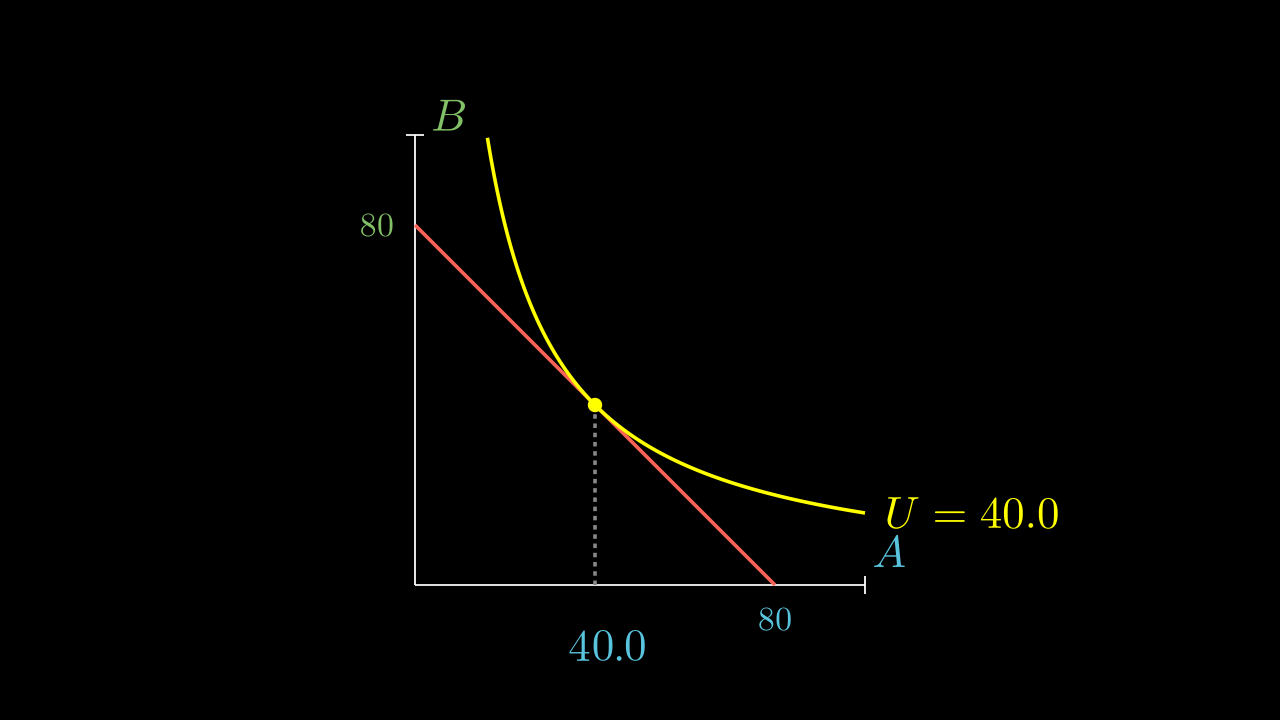

In [377]:
%%manim -qm -v ERROR animation_6

class animation_6(Scene):
    def construct(self):       
        price_a = ValueTracker(1)
        price_b = ValueTracker(1)
        Y = ValueTracker(80)
        
        """ Setup Base Axis """
        
        axes, axes_labels = consumer_graph()
        axes_group = VGroup(axes, axes_labels)
        self.add(axes, axes_labels)
        
        """ Setup Consumer Problem Graph """

        dot = always_redraw(lambda: effect_dot(axes, Y, price_a, price_b))
        budget = always_redraw(lambda: move_budget_constraint(axes, Y, price_a, price_b))
        indifference = always_redraw(lambda: effect_indifference(axes, Y, price_a, price_b))
        
        self.add(dot, budget, indifference)
        
        # add a base solution
        # add a hicks solution
        # and then add the live one
        
        """ Movements Along """
        
        
        
        """ Movements Between """
        
        
        
        """ Both Effects """
        
        

In [ ]:

        
        U_bar = ValueTracker(0)
        Y_delta = ValueTracker(0)

            
        def cobb_douglas_ind_hicks(a):
            if a > 0.1:
                return U_bar.get_value()**(1/(1-alpha))*a**(-alpha/(1-alpha))
            else:
                return 0
        
        def MRS_line(a):
            return cobb_douglas_MRS(a)*a+(q_a()-cobb_douglas_MRS(q_b())*q_b())
        
        def indifference_curve():
            indifference = axes.get_graph(cobb_douglas_indifference, color=YELLOW, x_range=(1, 150))
            
            x = q_a()
            x_int = axes.coords_to_point(x,0)
            x_label = DecimalNumber(num_decimal_places=1).set_color(BLUE).next_to(x_int,DOWN).set_value(x)
            
            y = q_b()
            y_int = axes.coords_to_point(0,y)
            y_label = DecimalNumber(num_decimal_places=1).set_color(GREEN).next_to(y_int,LEFT*2).set_value(y)
            
            p = axes.coords_to_point(x,y)
            dot = Dot(p).set_color(YELLOW)
            vline = DashedLine(x_int,p).set_color(GREY)
            hline = DashedLine(y_int,p).set_color(GREY)
            
            U_label = axes.get_graph_label(indifference, label="U = "+str(round(utility(),1)))

            return VGroup(indifference,U_label,dot,vline,hline,y_label,x_label)
        
        def hicks_a():
            return U_bar.get_value()*( alpha*p_b.get_value()/ ((1-alpha)*p_a.get_value()) )**(1-alpha)
        def hicks_b():
            return U_bar.get_value()*( (1-alpha)*p_a.get_value()/ (alpha*p_b.get_value()) )**alpha
        
        def expenditure_function():
            return p_a.get_value()*hicks_a() + p_b.get_value()*hicks_b()
        
        def hicks_bc_function(a):
            return (expenditure_function()-p_a.get_value()*a)/p_b.get_value()
        
        def hicks_constraint():
            budget_line = axes.get_graph(hicks_bc_function, color=RED, 
                                         x_range=(0, expenditure_function()/p_a.get_value()))
            Y_label = axes.get_graph_label(budget_line, 
                                           label="\\Delta Y = "+str(round(expenditure_function()-Y_delta.get_value())))
            return VGroup(budget_line,Y_label)
        
        def hicks_point():
            indifference = axes.get_graph(cobb_douglas_ind_hicks,
                                          color=YELLOW,
                                          x_range=(1, 150))
            
            x = hicks_a()
            x_int = axes.coords_to_point(x,0)
            x_label = DecimalNumber(num_decimal_places=1).set_color(BLUE).next_to(x_int,DOWN*3).set_value(x)
            
            y = hicks_b()
            y_int = axes.coords_to_point(0,y)
            y_label = DecimalNumber(num_decimal_places=1).set_color(GREEN).next_to(y_int,LEFT*2).set_value(y)
            
            p = axes.coords_to_point(x,y)
            dot = Dot(p).set_color(YELLOW)
            vline = DashedLine(x_int,p).set_color(GREY)
            hline = DashedLine(y_int,p).set_color(GREY)
            
            return VGroup(indifference,dot,vline,hline,x_label,y_label)
        
        def effects():
            a = axes.coords_to_point(90,0)
            b = axes.coords_to_point(hicks_a(),0)
            c = axes.coords_to_point(q_a(),0)

            sub_line = Line(b,a, color=GREEN)
            inc_line = Line(c,b, color=PINK)
            
            return VGroup(sub_line,inc_line)
        
        def effect_labels():
            sub_label = Tex("Substitution Effect").set_color(GREEN)
            inc_label = Tex("Income Effect").set_color(PINK)
            
            return VGroup(sub_label,inc_label).arrange(UP).to_edge(UP+RIGHT)

        
        """Consumer Problem Graph"""
        
        axes = Axes(
            x_range=[0, 150, 10],
            x_length = 9,
            x_axis_config={
                "numbers_to_include": [],
                "decimal_number_config": {"num_decimal_places":0},
            },
            y_range=[0, 150, 10],
            y_axis_config={
                "numbers_to_include": [],
                "decimal_number_config": {"num_decimal_places":0}
            },
            tips=False,
        )
        y_label = axes.get_y_axis_label("B")
        x_label = axes.get_x_axis_label("A")
        grid_labels = VGroup(x_label, y_label)
        
        self.add(axes, grid_labels)
        
        base_ind = axes.get_graph(cobb_douglas_indifference,
                                          color=YELLOW,
                                          x_range=(1, 150))
        base_x = q_a()
        base_x_int = axes.coords_to_point(base_x,0)
        base_x_label = DecimalNumber(num_decimal_places=1).set_color(BLUE).next_to(base_x_int,DOWN).set_value(base_x)

        base_y = q_b()
        base_y_int = axes.coords_to_point(0,base_y)
        base_y_label = DecimalNumber(num_decimal_places=1).set_color(GREEN).next_to(base_y_int,LEFT*2).set_value(base_y)

        base_p = axes.coords_to_point(base_x,base_y)
        base_dot = Dot(base_p).set_color(YELLOW)
        base_vline = DashedLine(base_x_int,base_p).set_color(GREY)
        base_hline = DashedLine(base_y_int,base_p).set_color(GREY)

        base_U_label = axes.get_graph_label(base_ind, label="U = "+str(round(utility(),1)))
        self.add(base_ind,base_x_label,base_y_label,base_dot,base_vline,base_hline,base_U_label)
        
        bc_line = always_redraw(budget_constraint)
        h_bc = always_redraw(hicks_constraint)
        ind_curve = always_redraw(indifference_curve)
        h_point = always_redraw(hicks_point)
        inc_sub_effects = always_redraw(effects)
        base_e = effects()
        
        self.add(bc_line,ind_curve,h_point,h_bc,inc_sub_effects)
        self.wait()
        
        """Run The Thing"""
        
        # Show the full effect
        self.play(p_a.animate.set_value(2),run_time=3)
        self.wait()
        self.add(base_e)
        self.play(Transform(base_e[0],effect_labels()[0]))
        self.wait()
        self.play(Transform(base_e[1],effect_labels()[1]))
        self.wait()
        self.play(FadeOut(bc_line),FadeOut(ind_curve),
                  FadeOut(inc_sub_effects),FadeOut(base_e))
        self.wait()
        
        # Show the ALONG effect
        self.play(p_a.animate.set_value(1),run_time=3)
        self.wait()
        self.add(inc_sub_effects[0])
        self.play(p_a.animate.set_value(2),run_time=3)
        self.wait()
        self.play(Transform(base_e[0],effect_labels()[0]))
        self.wait()
        self.do_framebox(h_bc[1],1/4)
        self.wait()
        self.do_framebox(base_U_label,1/4)
        self.wait()
        
        # Show the ACROSS effect
        Y.set_value(expenditure_function())
        self.wait()
        self.add(bc_line,ind_curve,inc_sub_effects,base_e)
        self.wait()
        self.play(Y.animate.set_value(180),run_time=3)
        self.wait()
        self.do_framebox(h_bc[1],1/4)
        self.wait()
        self.do_framebox(ind_curve[1],1/4)
        self.wait()

This video still needs work. It's not clear why B should end up back where it was. Show the original budget line, which will make it easier to see the price change. 

### Convert MP4 Videos to MOV

In [ ]:
video_path = config.media_dir+'/videos/tutorials/1080p60/'

manim_to_mov(video_path)